# Plotting in Python
Below are some examples of plots in python using the matplotlib library.


In [23]:
import numpy as np
import math
from matplotlib import pyplot as plt
from ipywidgets import interactive, fixed

In [24]:
# Fixed-Point Iteration -------------> modified to apply Newton's Method
# Computes approximate solution of f(x) = 0

# Input: starting guess p0,
#        number of steps k

# Output: Approximate solution pn
def newton(p0,k, D, epsilon, Re):

    # initialize
    pn = np.zeros(k+1)
    pn[0] = p0

    print("n = ",0,":","pn = ",pn[0])

    for i in range(k):
        pn[i+1] = pn[i] - F(pn[i], D, epsilon, Re) / dF(pn[i], D, epsilon, Re)

    return pn

In [25]:
# Defining the objective function F(x) = 0 and its derivative F'(x)
# Using x = 1 / sqrt(f) to keep the derivative straightforward
def F(x, D, epsilon, Re):
    return x + 2.0 * np.log10((epsilon / (3.7 * D)) + (2.51 * x / Re))

def dF(x, D, epsilon, Re):
    inner = (epsilon / (3.7 * D)) + (2.51 * x / Re)
    return 1.0 + (2.0 / np.log(10)) * (2.51 / Re) / inner

COLEBROOK EQUATION

In [26]:
D = 0.3          # Pipe diameter (m)
epsilon = 0.0002 # Roughness height (m)
k_steps = 6      # # Number of iterations per solution
Re_single = 10**5
x0 = 7.0

x_history = newton(x0, k_steps, D, epsilon, Re_single)
f_history = 1.0 / (x_history**2)

print("--- Part (i) Convergence ---")
for step, f_val in enumerate(f_history):
    print(f"Iteration {step}: f = {f_val:.7f}")

print(f"\nFinal Darcy number f for Re = 10^5: {f_history[-1]:.6f}")

n =  0 : pn =  7.0
--- Part (i) Convergence ---
Iteration 0: f = 0.0204082
Iteration 1: f = 0.0209838
Iteration 2: f = 0.0209837
Iteration 3: f = 0.0209837
Iteration 4: f = 0.0209837
Iteration 5: f = 0.0209837
Iteration 6: f = 0.0209837

Final Darcy number f for Re = 10^5: 0.020984


n =  0 : pn =  7.0
n =  0 : pn =  5.599572767577199
n =  0 : pn =  5.662319851302784
n =  0 : pn =  5.724596887966802
n =  0 : pn =  5.786360914764413
n =  0 : pn =  5.847567028033233
n =  0 : pn =  5.908168427908427
n =  0 : pn =  5.968116491787559
n =  0 : pn =  6.027360880180914
n =  0 : pn =  6.085849678430268
n =  0 : pn =  6.143529577546412
n =  0 : pn =  6.200346097016624
n =  0 : pn =  6.256243851844079
n =  0 : pn =  6.311166865282099
n =  0 : pn =  6.36505892770461
n =  0 : pn =  6.417864000808114
n =  0 : pn =  6.469526664881288
n =  0 : pn =  6.519992605233724
n =  0 : pn =  6.569209132092319
n =  0 : pn =  6.617125726419149
n =  0 : pn =  6.663694602265027
n =  0 : pn =  6.708871274551922
n =  0 : pn =  6.752615119690987
n =  0 : pn =  6.7948899153116695
n =  0 : pn =  6.83566434471716
n =  0 : pn =  6.874912451592056
n =  0 : pn =  6.912614031042069
n =  0 : pn =  6.948754944277446
n =  0 : pn =  6.983327346149768
n =  0 : pn =  7.016329817254281
n =  0 : pn =  7.04776739

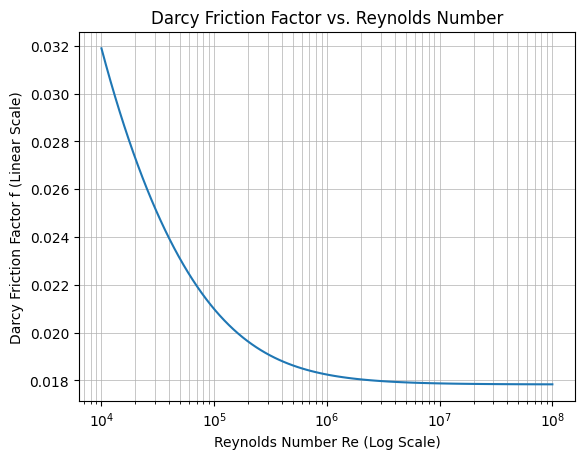

In [27]:
# Generate Reynolds numbers between 10^4 and 10^8 on a log scale
Re_vals = np.logspace(4, 8, 100)
f_vals = []

# Loop through Reynolds numbers and run Newton's method for each
for Re in Re_vals:
    x_sol = newton(x0, k_steps, D, epsilon, Re)[-1]
    f_vals.append(1.0 / (x_sol**2))
    x0 = x_sol


x = Re_vals
y = f_vals

plt.plot(x, y)
plt.xscale('log') # Set x-axis to logarithmic scale
# plt.yscale('log') # y-axis remains linear
plt.title('Darcy Friction Factor vs. Reynolds Number')
plt.xlabel('Reynolds Number Re (Log Scale)')
plt.ylabel('Darcy Friction Factor f (Linear Scale)')
plt.grid(True, which="both", ls="-", lw=0.5) # Add grid for better visualization
plt.show()
